# Regressão Linear com PyTorch

## Objetivo

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se
- o cálculo do gradiente automático do PyTorch, porém
- a função de perda e
- atualização dos parâmetros é feita de forma explícita.
- A rede é criada com uma camada nn.Linear()

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinear_Otimizacao.png)

## Importação dos pacotes

In [159]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
from sklearn.datasets import load_iris

import torch
from torch import nn, optim
from torch.autograd import Variable

torch.manual_seed(1234)

## Leitura dos dados

In [160]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1].astype(np.float32)
y_train = data[:,1:2].astype(np.float32)

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float32
y_train.shape: (50, 1) float32
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [161]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()


In [162]:
print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train[:5]:
 [[1.        ]
 [0.71428573]
 [0.952381  ]
 [0.28571424]
 [0.7619048 ]]
y_train[:5]:
 [[0.80952376]
 [0.71428573]
 [0.90476197]
 [0.4761905 ]
 [0.7619048 ]]


In [163]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [164]:
x_train_bias

array([[1.        , 1.        ],
       [1.        , 0.71428573],
       [1.        , 0.95238101],
       [1.        , 0.28571424],
       [1.        , 0.76190478],
       [1.        , 0.38095227],
       [1.        , 0.66666675],
       [1.        , 0.        ],
       [1.        , 0.80952376],
       [1.        , 0.14285702],
       [1.        , 0.047619  ],
       [1.        , 0.47619051],
       [1.        , 0.52380949],
       [1.        , 0.57142848],
       [1.        , 0.33333325],
       [1.        , 0.85714275],
       [1.        , 0.33333325],
       [1.        , 0.42857149],
       [1.        , 0.61904752],
       [1.        , 0.33333325],
       [1.        , 0.47619051],
       [1.        , 0.57142848],
       [1.        , 0.66666675],
       [1.        , 0.57142848],
       [1.        , 0.71428573],
       [1.        , 0.80952376],
       [1.        , 0.90476197],
       [1.        , 0.85714275],
       [1.        , 0.52380949],
       [1.        , 0.38095227],
       [1.

In [165]:
print('x_train_bias.shape:',x_train_bias.shape, x_train_bias.dtype)

x_train_bias.shape: (50, 2) float64


In [166]:
#convertendo pra Tensor
x_train_bias = torch.FloatTensor(x_train_bias)
y_train      = torch.FloatTensor(y_train)
print(y_train)

tensor([[0.8095],
        [0.7143],
        [0.9048],
        [0.4762],
        [0.7619],
        [0.7143],
        [0.8095],
        [0.1429],
        [0.7619],
        [0.4286],
        [0.2381],
        [0.5714],
        [0.4762],
        [0.8095],
        [0.2857],
        [0.6667],
        [0.7143],
        [0.5238],
        [0.7143],
        [0.4286],
        [0.8571],
        [0.4762],
        [0.9048],
        [0.8095],
        [0.6190],
        [0.6667],
        [0.8571],
        [0.9524],
        [0.7143],
        [0.2381],
        [0.3810],
        [0.3333],
        [0.4286],
        [1.0000],
        [0.7143],
        [0.7143],
        [0.8095],
        [0.6667],
        [0.5238],
        [0.4762],
        [0.6667],
        [0.7619],
        [0.4762],
        [0.1429],
        [0.5714],
        [0.5714],
        [0.5714],
        [0.6190],
        [0.0000],
        [0.5238]])


## Model

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinearNeuronio.png)

In [167]:
#Inicialização usando toch.nn.Linear

model = torch.nn.Linear(in_features=2, out_features=1, bias=False)

In [168]:
model

Linear(in_features=2, out_features=1, bias=False)

In [169]:
model.weight.data #inicializa os pesos automaticamente, mas precisa limpar depois e reiniciar

tensor([[-0.6661, -0.1387]])

### Verificando a inicialização dos parâmetros

In [170]:
#limpando os pesos e reiniciando com valores específicos )entre -0,1 e 0,1)
model.weight.data = torch.zeros(1,2)
torch.nn.init.uniform(model.weight.data, -0.1, 0.1)
model.weight

/tmp/ipykernel_22347/122985069.py:3: FutureWarning: `nn.init.uniform` is now deprecated in favor of `nn.init.uniform_`.
  torch.nn.init.uniform(model.weight.data, -0.1, 0.1)


Parameter containing:
tensor([[-0.0480, -0.0267]], requires_grad=True)

### Testando o predict da rede

In [171]:
xx = torch.ones((5,2))
xx

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])

In [172]:
#model(Variable(xx)) #deprecated
model(xx)

tensor([[-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747]], grad_fn=<MmBackward0>)

In [173]:
#testar a rede com o x_train_bias. Se rodar é pq funcionou a rede
model(x_train_bias)

tensor([[-0.0747],
        [-0.0671],
        [-0.0734],
        [-0.0557],
        [-0.0684],
        [-0.0582],
        [-0.0658],
        [-0.0480],
        [-0.0696],
        [-0.0518],
        [-0.0493],
        [-0.0607],
        [-0.0620],
        [-0.0633],
        [-0.0569],
        [-0.0709],
        [-0.0569],
        [-0.0595],
        [-0.0645],
        [-0.0569],
        [-0.0607],
        [-0.0633],
        [-0.0658],
        [-0.0633],
        [-0.0671],
        [-0.0696],
        [-0.0722],
        [-0.0709],
        [-0.0620],
        [-0.0582],
        [-0.0557],
        [-0.0557],
        [-0.0595],
        [-0.0620],
        [-0.0544],
        [-0.0620],
        [-0.0709],
        [-0.0658],
        [-0.0569],
        [-0.0557],
        [-0.0557],
        [-0.0633],
        [-0.0595],
        [-0.0493],
        [-0.0569],
        [-0.0582],
        [-0.0582],
        [-0.0645],
        [-0.0506],
        [-0.0582]], grad_fn=<MmBackward0>)

## Treinamento

In [174]:
num_epochs = 100
learning_rate = 0.5

w0_list = []
w1_list = []

for epoch in range(num_epochs):
    #inputs = Variable(x_train_bias)
    #target = Variable(y_train)
    inputs = x_train_bias
    target = y_train

    # 1) forward - predict
    y_pred = model(inputs)


    # Exercício 3 - armazena os pesos
    w0_list.append(model.weight.data[0][0].item())
    w1_list.append(model.weight.data[0][1].item())

    # 2) loss cálculo da função de perda
    loss = torch.mean((y_pred - target)**2)

    # 3) backward propagation - cálculo gradient
    loss.backward() # calcula o gradiente descendente (substitui o cálculo manual que fazíamos antes no colab anterior)

    # 4) gradiente descendente - atualização dos pesos
    model.weight.data = model.weight.data - learning_rate * model.weight.grad.data #"grad.data" é o peso calculado no grandiente descendente pelo loss.backward

    # zeragem parâmetros próximo cálculo do gradiente
    model.weight.grad.data.zero_()

    # verbose
    if (epoch+1) % 2 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss.data) + ' -> w0: ' + str(model.weight.data[0][0].item()) + ' w1: ' + str(model.weight.data[0][1].item()))


Epoch[2/100], loss: 0.061238 -> w0: 0.4314092993736267 w1: 0.2724859416484833
Epoch[4/100], loss: 0.029806 -> w0: 0.44516679644584656 w1: 0.32584553956985474
Epoch[6/100], loss: 0.028185 -> w0: 0.43015623092651367 w1: 0.3600521385669708
Epoch[8/100], loss: 0.026952 -> w0: 0.4147339463233948 w1: 0.39017945528030396
Epoch[10/100], loss: 0.025936 -> w0: 0.40061497688293457 w1: 0.4174714684486389
Epoch[12/100], loss: 0.025098 -> w0: 0.38778868317604065 w1: 0.4422459900379181
Epoch[14/100], loss: 0.024408 -> w0: 0.3761431872844696 w1: 0.4647385776042938
Epoch[16/100], loss: 0.023839 -> w0: 0.36557015776634216 w1: 0.48515960574150085
Epoch[18/100], loss: 0.023370 -> w0: 0.3559708893299103 w1: 0.5036998987197876
Epoch[20/100], loss: 0.022983 -> w0: 0.34725573658943176 w1: 0.5205326676368713
Epoch[22/100], loss: 0.022664 -> w0: 0.33934319019317627 w1: 0.5358151793479919
Epoch[24/100], loss: 0.022402 -> w0: 0.3321593999862671 w1: 0.5496901869773865
Epoch[26/100], loss: 0.022185 -> w0: 0.3256371

In [175]:
loss

tensor(0.0212, grad_fn=<MeanBackward0>)

## Avaliação

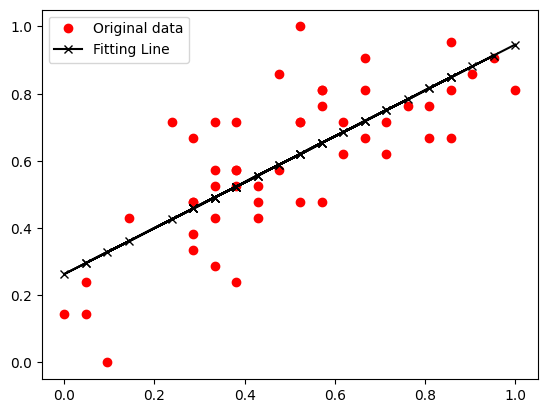

In [176]:
y_pred = model(Variable(x_train_bias))
plt.plot(x_train, y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train, y_pred.data.numpy(), 'kx-', label='Fitting Line')
plt.legend()
plt.show()

### Acessando os parâmetros

In [177]:
model.weight.data # acessa os pesos utilizados

tensor([[0.2631, 0.6830]])

In [178]:
w_dic = model.state_dict() # salva os pesos
w_dic

OrderedDict([('weight', tensor([[0.2631, 0.6830]]))])

### Parâmetros ótimos, solução analítica

In [179]:
x_bias = x_train_bias
y = y_train
x_bias_t = torch.t(x_bias)
w_opt = (torch.inverse(x_bias_t.mm(x_bias)).mm(x_bias_t)).mm(y)
print(torch.t(w_opt))

tensor([[0.2613, 0.6865]])


# Exercícios

- 1) Por que no final da varredura do laço de treinamento, a perda é impressa utilizando
   `loss.data`? Por que precisa do `data`?
   **R. Porque loss é um objeto do tipo Tensor, então precisa utilizar o "loss.data" para retornar apenas o atributo correspondente ao valor da perda**
   

- 2) Calcule e imprima o valor da perda (MSE) fazendo o predict da rede com os pesos já
   treinados.

- 3) Crie duas listas `w0_list` e `w1_list` para guardar a evolução dos valores dos
   parâmetros durante o laço de treinamento.
   Modifique o exemplo do gráfico tipo **scatter plot** para visualizar a variação
   dos parâmetros do modelo duas dimensões.
   Marque neste gráfico o valor ótimo do parâmetro dado pela solução
   analítica.

## Ploting vectors

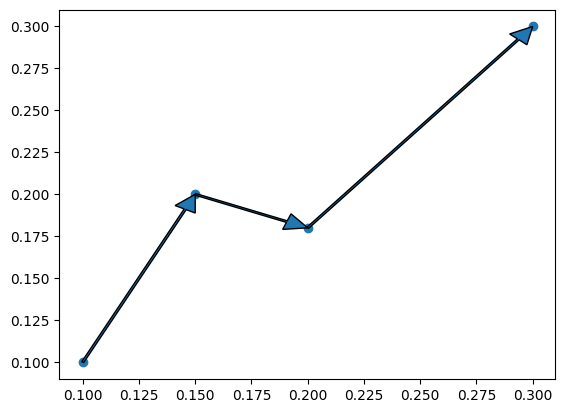

In [180]:
# Exemplo
w0_list_exemplo = [0.1, 0.15, 0.2, 0.3]
w1_list_exemplo = [0.1, 0.2, 0.18, 0.3]
plt.scatter(w0_list_exemplo,w1_list_exemplo)
w0_old = None
for (w0,w1) in zip(w0_list_exemplo,w1_list_exemplo):
    if w0_old:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.01,head_width=0.01,shape='full',
                  length_includes_head=True)
    w0_old,w1_old = w0,w1

## Exercício 2

In [181]:
# Exercício 2 - fazendo o predict da rede com os pesos já treinados
model.weight

Parameter containing:
tensor([[0.2631, 0.6830]], requires_grad=True)

In [182]:
y_pred = model(Variable(x_train_bias))
loss_MSE = torch.mean((y_pred - y_train)**2)
print('loss_MSE:',loss_MSE.data)

loss_MSE: tensor(0.0212)


## Exercício 3

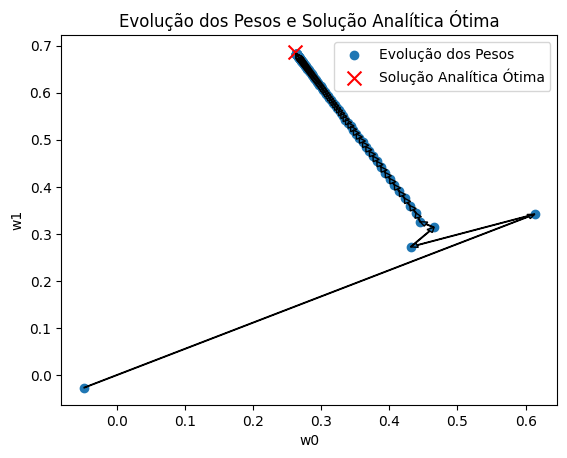

In [183]:
# Exercício 3 - plotando os valores reais de w0_list e w1_list
plt.scatter(w0_list,w1_list, label='Evolução dos Pesos')

# Adicionando o valor ótimo do parâmetro dado pela solução analítica
w_opt_w0 = w_opt[0]
w_opt_w1 = w_opt[1]
plt.scatter(w_opt_w0, w_opt_w1, marker='x', color='red', s=100, label='Solução Analítica Ótima')

w0_old = None
for (w0,w1) in zip(w0_list,w1_list):
    if w0_old:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.01,head_width=0.01,shape='full',
                  length_includes_head=True)
    w0_old,w1_old = w0,w1

plt.xlabel('w0')
plt.ylabel('w1')
plt.title('Evolução dos Pesos e Solução Analítica Ótima')
plt.legend()
plt.show()

# Aprendizados

Pelo algoritmo de treinamento, observamos que após aproximadamente a época 70, os valores dos pesos w0 e w1 não apresentam um ganho tão significativo. Ou seja, poderíamos ter encerrado o treinamento um pouco antes das 100 épocas, sem comprometer o resultado.